In [206]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import holidays
from xgboost import XGBRegressor

In [207]:
filename = 'data/final_generation_minimized.csv'
df = pd.read_csv(filename)
df.head(), df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396244 entries, 0 to 396243
Data columns (total 3 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   DateTime(UTC)               396244 non-null  object 
 1   ActualGenerationOutput[MW]  396244 non-null  float64
 2   ActualConsumption[MW]       396244 non-null  float64
dtypes: float64(2), object(1)
memory usage: 9.1+ MB


(         DateTime(UTC)  ActualGenerationOutput[MW]  ActualConsumption[MW]
 0  2015-01-01 00:00:00                    50247.45                1343.52
 1  2015-01-01 00:15:00                    49992.52                1329.77
 2  2015-01-01 00:30:00                    49587.40                1385.19
 3  2015-01-01 00:45:00                    49000.85                1431.61
 4  2015-01-01 01:00:00                    49377.68                1938.83,
 None)

In [208]:
train_date = "2026-01-01"

In [209]:
df_truncated.shape

(45413, 26)

In [210]:
start_date = "2025-01-01 01:00:00"
end_date   = "2026-04-19 02:00:00"
# determine the train test split at the same time 

df["DateTime(UTC)"] = pd.to_datetime(df["DateTime(UTC)"])
df = df.sort_values("DateTime(UTC)")
df = df.set_index("DateTime(UTC)")
df_truncated = df.loc[start_date:end_date]
df_truncated = df_truncated.reset_index()
df_truncated.describe().T


,count,mean,min,25%,50%,75%,max,std
DateTime(UTC),45413,2025-08-25 13:30:00,2025-01-01 01:00:00,2025-04-29 07:15:00,2025-08-25 13:30:00,2025-12-21 19:45:00,2026-04-19 02:00:00,NaN
ActualGenerationOutput[MW],45413.0,51681.970669,18363.571,43295.11,52107.32,60059.317816,84324.32,11319.438438
ActualConsumption[MW],45413.0,11100.102661,0.0033,21.34,422.2808,2613.46,178364918.531,1072047.401706


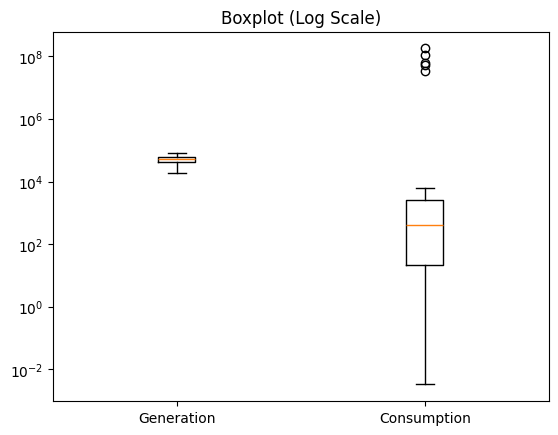

In [211]:
plt.figure()
plt.boxplot([df_truncated["ActualGenerationOutput[MW]"], df_truncated["ActualConsumption[MW]"]], tick_labels=["Generation", "Consumption"])
plt.yscale("log")
plt.title("Boxplot (Log Scale)")
plt.show()

In [212]:
# Just note that there are extreme consumption in these few rows. I will subtract the consumtion 
# from generation to use net generation as feature

df_truncated[df_truncated["ActualConsumption[MW]"] > 10e2].shape, df_truncated.shape
df_truncated[df_truncated["ActualConsumption[MW]"] > 10e3]

,DateTime(UTC),ActualGenerationOutput[MW],ActualConsumption[MW]
45073,2026-04-15 13:15:00,57012.47235,1.783649e+08
45076,2026-04-15 14:00:00,55279.19774,1.121502e+08
45084,2026-04-15 16:00:00,43818.54776,5.428365e+07
45085,2026-04-15 16:15:00,43171.44956,3.400182e+07
45087,2026-04-15 16:45:00,43093.03522,6.084537e+07


In [213]:
df_truncated['NetGeneration[MW]'] = df_truncated['ActualGenerationOutput[MW]'] - df_truncated['ActualConsumption[MW]']


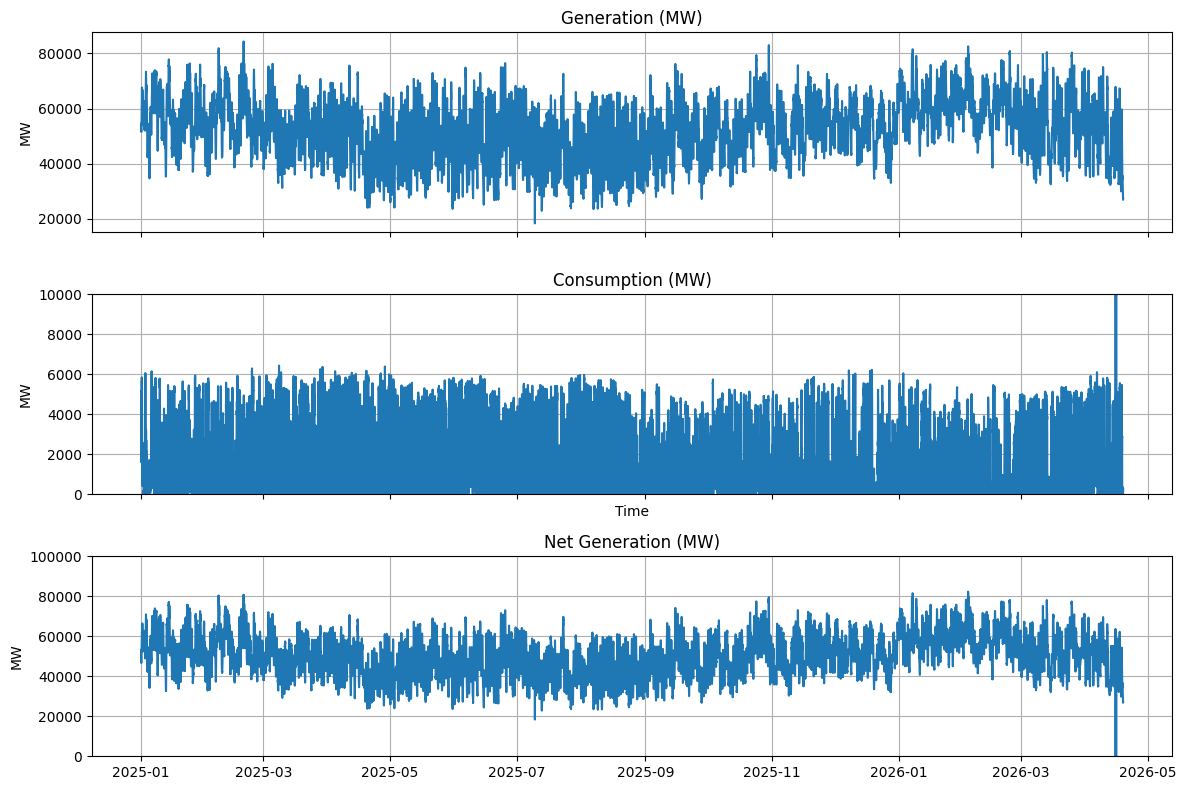

In [214]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Generation plot
axes[0].plot(df_truncated['DateTime(UTC)'], df_truncated['ActualGenerationOutput[MW]'])
axes[0].set_title('Generation (MW)')
axes[0].set_ylabel('MW')
axes[0].grid(True)

# Consumption plot
axes[1].plot(df_truncated['DateTime(UTC)'], df_truncated['ActualConsumption[MW]'])
axes[1].set_title('Consumption (MW)')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('MW')
axes[1].grid(True)
axes[1].set_ylim(0, 10e3)

axes[2].plot(df_truncated['DateTime(UTC)'], df_truncated['NetGeneration[MW]'])
axes[2].set_title('Net Generation (MW)')
axes[2].set_ylabel('MW')
axes[2].grid(True)
axes[2].set_ylim(0, 10e4)

plt.tight_layout()
plt.show()

In [215]:
# ---- Basic time features ----
df_truncated["day_of_week"] = df_truncated["DateTime(UTC)"].dt.dayofweek
df_truncated["day_of_year"] = df_truncated["DateTime(UTC)"].dt.dayofyear
df_truncated["month"] = df_truncated["DateTime(UTC)"].dt.month
df_truncated["year"] = df_truncated["DateTime(UTC)"].dt.year

# ---- Hour + quarter-hour ----
df_truncated["hour"] = df_truncated["DateTime(UTC)"].dt.hour

# quarter of hour: 0,1,2,3
df_truncated["quarter_hour"] = df_truncated["DateTime(UTC)"].dt.minute // 15

# ---- German public holidays ----
years = df_truncated["year"].unique()
de_holidays = holidays.Germany(years=years)

df_truncated["is_holiday"] = df_truncated["DateTime(UTC)"].dt.floor("D").isin(de_holidays)

# ---- Bridge day (Brückentag) ----
# A bridge day is typically:
# - Monday before a Tuesday holiday
# - Friday after a Thursday holiday

df_truncated["date"] = df_truncated["DateTime(UTC)"].dt.date

holidays_set = set(de_holidays)

def is_bridge_day(date):
    weekday = date.weekday()
    
    # Monday before Tuesday holiday
    if weekday == 0 and (date + pd.Timedelta(days=1)) in holidays_set:
        return 1
    
    # Friday after Thursday holiday
    if weekday == 4 and (date - pd.Timedelta(days=1)) in holidays_set:
        return 1
    
    return 0

df_truncated["is_bridge_day"] = df_truncated["date"].apply(is_bridge_day)

# convert holiday boolean to int
df_truncated["is_holiday"] = df_truncated["is_holiday"].astype(int)

/tmp/ipykernel_75606/1771040005.py:17: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_truncated["is_holiday"] = df_truncated["DateTime(UTC)"].dt.floor("D").isin(de_holidays)


In [216]:
df_truncated["is_bridge_day"].value_counts()

is_bridge_day
0    45029
1      384
Name: count, dtype: int64

In [217]:
# Rolling mean
df_truncated["netgen_roll_mean_4"] = df_truncated["NetGeneration[MW]"].rolling(4).mean()
df_truncated["netgen_roll_mean_24"] = df_truncated["NetGeneration[MW]"].rolling(24).mean()
df_truncated["netgen_roll_mean_96"] = df_truncated["NetGeneration[MW]"].rolling(96).mean()
df_truncated["netgen_roll_mean_672"] = df_truncated["NetGeneration[MW]"].rolling(672).mean()

# Rolling std
df_truncated["netgen_roll_std_4"] = df_truncated["NetGeneration[MW]"].rolling(4).std()
df_truncated["netgen_roll_std_24"] = df_truncated["NetGeneration[MW]"].rolling(24).std()
df_truncated["netgen_roll_std_96"] = df_truncated["NetGeneration[MW]"].rolling(96).std()

df_truncated["netgen_lag_1"] = df_truncated["NetGeneration[MW]"].shift(1)
df_truncated["netgen_lag_4"] = df_truncated["NetGeneration[MW]"].shift(4)
df_truncated["netgen_lag_12"] = df_truncated["NetGeneration[MW]"].shift(12)   # 3 hours
df_truncated["netgen_lag_24"] = df_truncated["NetGeneration[MW]"].shift(24)   # 6 hours
df_truncated["netgen_lag_96"] = df_truncated["NetGeneration[MW]"].shift(96)   # 1 day
df_truncated["netgen_lag_672"] = df_truncated["NetGeneration[MW]"].shift(672) # 1 week



In [218]:
# Net Generation data is done now. Now process target column
df_y = pd.read_csv('data/combined_energy_price_clean.csv', sep='\t')
df_y["DateTime(UTC)"] = pd.to_datetime(df_y["DateTime(UTC)"])
df_y = df_y.sort_values("DateTime(UTC)")
df_y = df_y.set_index("DateTime(UTC)")
df_y_truncated = df_y.loc[start_date:end_date]
df_y_truncated = df_y_truncated.reset_index()
df_y_truncated = df_y_truncated[df_y_truncated["Sequence"] != 1]

/tmp/ipykernel_75606/1455107288.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_y = pd.read_csv('data/combined_energy_price_clean.csv', sep='\t')


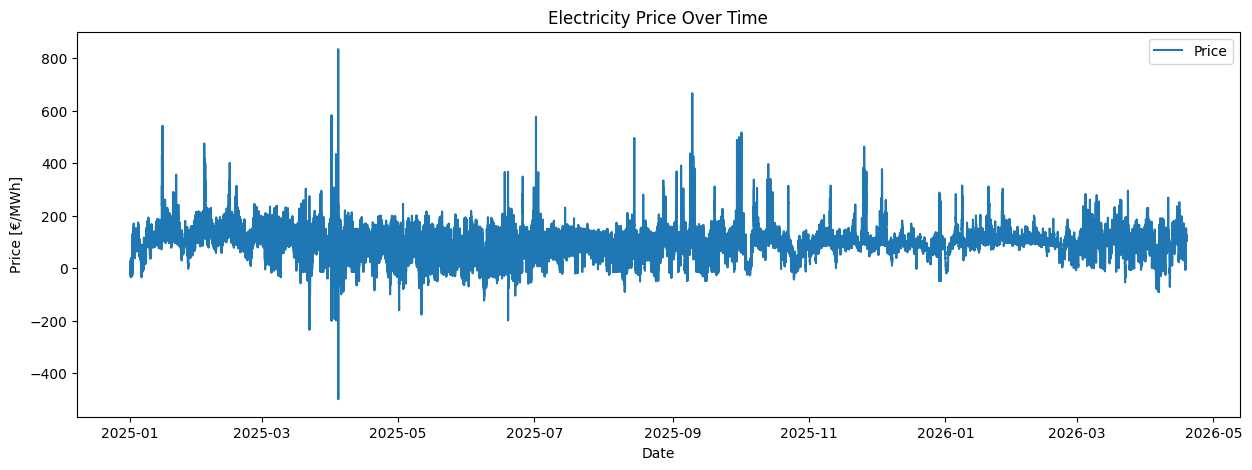

In [219]:
plt.figure(figsize=(15,5))

plt.plot(df_y_truncated["DateTime(UTC)"], df_y_truncated["Price[Currency/MWh]"], label="Price")

plt.xlabel("Date")
plt.ylabel("Price [€/MWh]")
plt.title("Electricity Price Over Time")
plt.legend()

plt.show()

In [220]:
(df_y_truncated["DateTime(UTC)"].reset_index(drop=True) ==
 df_truncated["DateTime(UTC)"].reset_index(drop=True)).all(), df_truncated.shape, df_y_truncated.shape

(True, (45413, 26), (45413, 7))

In [221]:
#both dataframes have the same datetime, we can combine them 
df_merged = df_truncated.merge(
    df_y_truncated[["DateTime(UTC)", "Price[Currency/MWh]"]],
    on="DateTime(UTC)",
    how="left"
)
df_merged.rename(columns={"NetGeneration[MW]": "NetGeneration_MW"}, inplace=True)
df_merged.head()

,DateTime(UTC),ActualGenerationOutput[MW],ActualConsumption[MW],NetGeneration_MW,day_of_week,day_of_year,month,year,hour,quarter_hour,...,netgen_roll_std_4,netgen_roll_std_24,netgen_roll_std_96,netgen_lag_1,netgen_lag_4,netgen_lag_12,netgen_lag_24,netgen_lag_96,netgen_lag_672,Price[Currency/MWh]
0,2025-01-01 01:00:00,53794.24,1625.80,52168.44,2,1,1,2025,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.60
1,2025-01-01 01:15:00,53889.47,2103.82,51785.65,2,1,1,2025,1,1,...,NaN,NaN,NaN,52168.44,NaN,NaN,NaN,NaN,NaN,-0.50
2,2025-01-01 01:30:00,53642.49,2521.47,51121.02,2,1,1,2025,1,2,...,NaN,NaN,NaN,51785.65,NaN,NaN,NaN,NaN,NaN,-6.51
3,2025-01-01 01:45:00,53483.38,2749.03,50734.35,2,1,1,2025,1,3,...,645.284781,NaN,NaN,51121.02,NaN,NaN,NaN,NaN,NaN,-3.50
4,2025-01-01 02:00:00,52040.88,2225.98,49814.90,2,1,1,2025,2,0,...,823.188503,NaN,NaN,50734.35,52168.44,NaN,NaN,NaN,NaN,-1.05


In [222]:
df_model = df_merged.sort_values("DateTime(UTC)").copy()
df_model["target_288"] = df_model["Price[Currency/MWh]"].shift(-288)
df_model = df_model.dropna().reset_index(drop=True)

In [223]:
split_date = pd.Timestamp(train_date)
split_idx = df_model[df_model["DateTime(UTC)"] <= split_date].index.max()
split_idx

34364

In [224]:
train = df_model.iloc[:split_idx + 1]
test = df_model.iloc[split_idx + 1:]
print(train["DateTime(UTC)"].max())
print(test["DateTime(UTC)"].min())

2026-01-01 00:00:00
2026-01-01 00:15:00


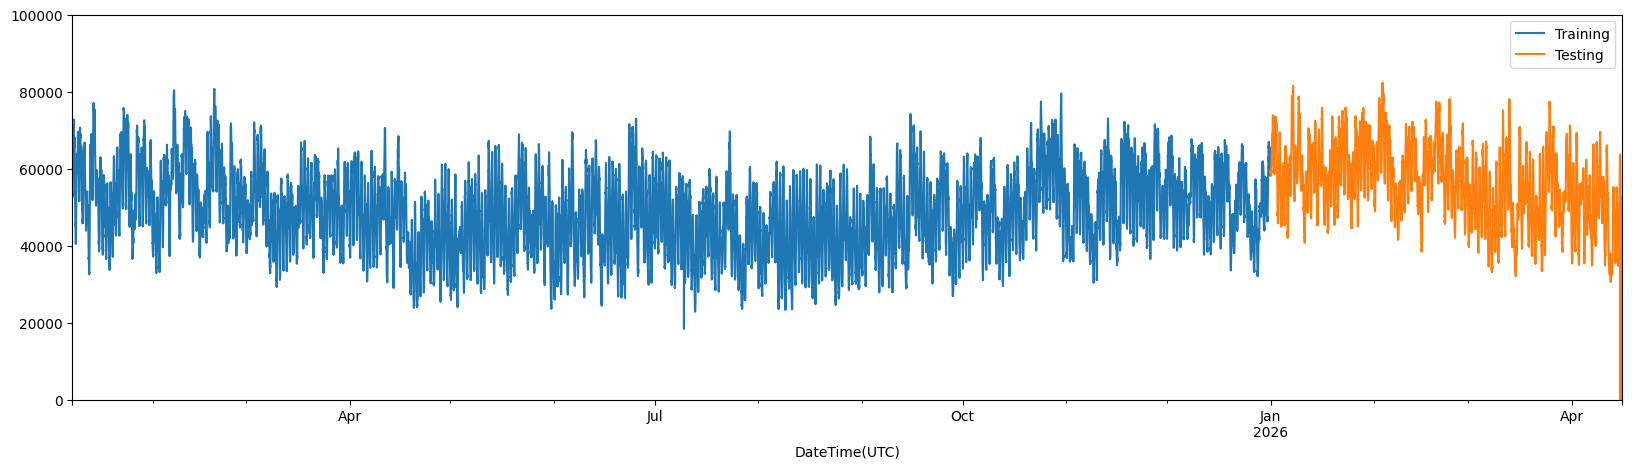

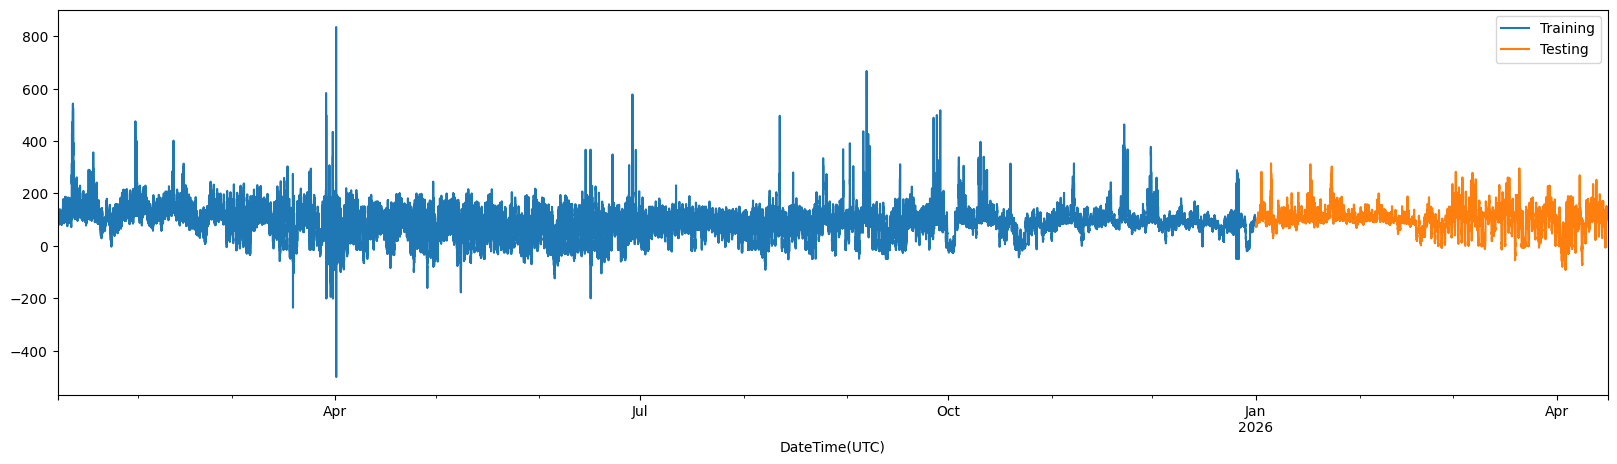

In [225]:
figure, ax = plt.subplots(figsize=(20, 5))
train.plot(ax=ax, label="Training", x="DateTime(UTC)", y="NetGeneration_MW")
test.plot(ax=ax, label="Testing", x="DateTime(UTC)", y="NetGeneration_MW")
ax.set_ylim(0, 10e4)

plt.show()

figure, ax = plt.subplots(figsize=(20, 5))
train.plot(ax=ax, label="Training", x="DateTime(UTC)", y="target_288")
test.plot(ax=ax, label="Testing", x="DateTime(UTC)", y="target_288")

plt.show()

In [226]:
columns_to_drop = [
    "DateTime(UTC)",
    "ActualGenerationOutput[MW]",
    "ActualConsumption[MW]",
    "date",
    "Price[Currency/MWh]", 
    "target_288"
]
X_train = train.drop(columns=columns_to_drop)
y_train = train["target_288"]
X_test = test.drop(columns=columns_to_drop)
y_test = test["target_288"]
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((34365, 22), (34365,), (10088, 22), (10088,))

In [227]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [228]:
y_pred = model.predict(X_test)

In [229]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 39.060249268231566
RMSE: 47.78620733998306


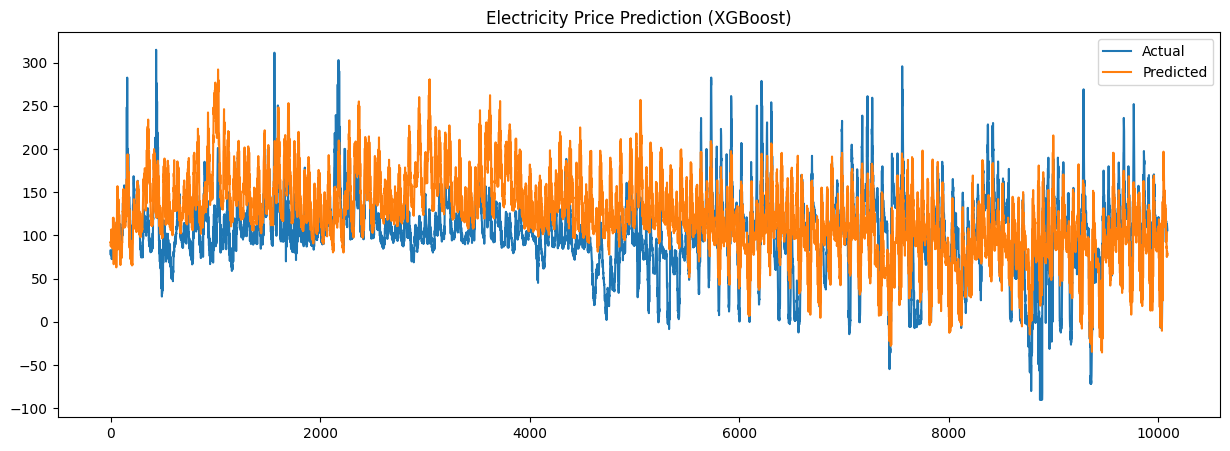

In [230]:
plt.figure(figsize=(15,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Electricity Price Prediction (XGBoost)")
plt.show()

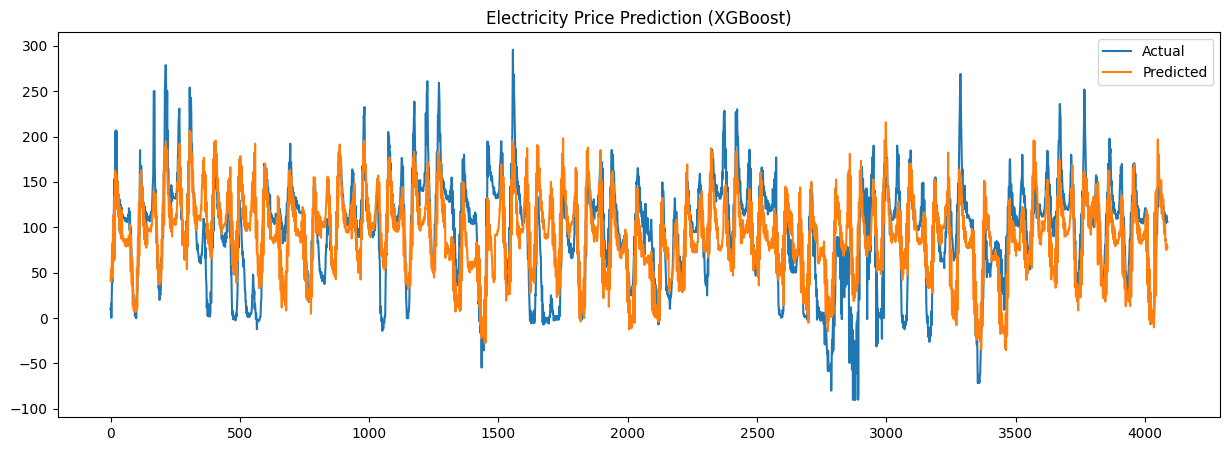

In [231]:
plt.figure(figsize=(15,5))

plt.plot(y_test.values[6000:], label="Actual")
plt.plot(y_pred[6000:], label="Predicted")

plt.legend()
plt.title("Electricity Price Prediction (XGBoost)")
plt.show()

2026-01-01 00:00:00
2026-01-01 00:15:00
MAE: 31.315438505714482
RMSE: 39.580531698085245


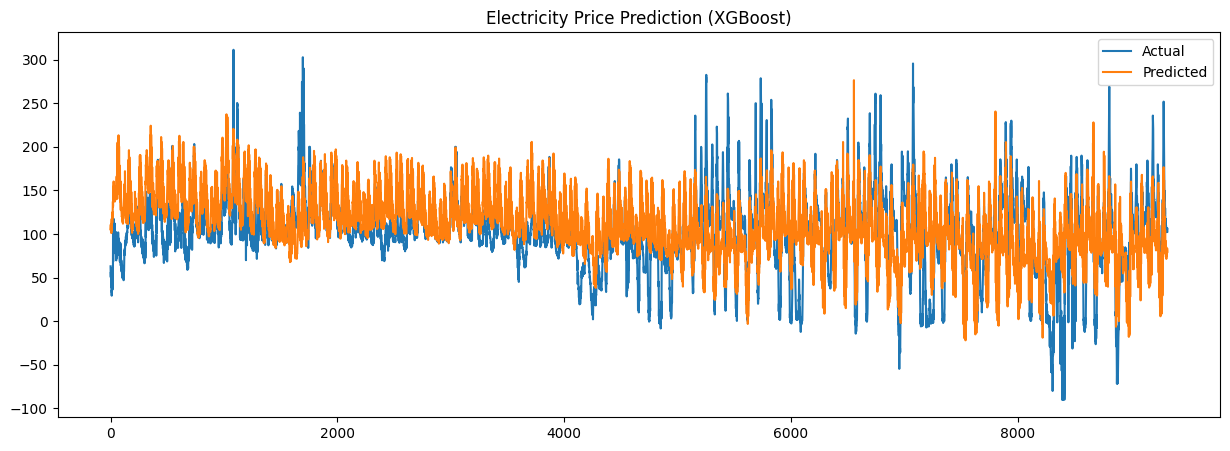

In [172]:
# Repeat with only one day prediction

df_model_96 = df_merged.sort_values("DateTime(UTC)").copy()
df_model_96["target_96"] = df_model["Price[Currency/MWh]"].shift(-96)
df_model_96 = df_model_96.dropna().reset_index(drop=True)
train = df_model_96.iloc[:split_idx + 1]
test = df_model_96.iloc[split_idx + 1:]
print(train["DateTime(UTC)"].max())
print(test["DateTime(UTC)"].min())

columns_to_drop = [
    "DateTime(UTC)",
    "ActualGenerationOutput[MW]",
    "ActualConsumption[MW]",
    "date",
    "Price[Currency/MWh]", 
    "target_96"
]

X_train = train.drop(columns=columns_to_drop)
y_train = train["target_96"]
X_test = test.drop(columns=columns_to_drop)
y_test = test["target_96"]
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

plt.figure(figsize=(15,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Electricity Price Prediction (XGBoost)")
plt.show()

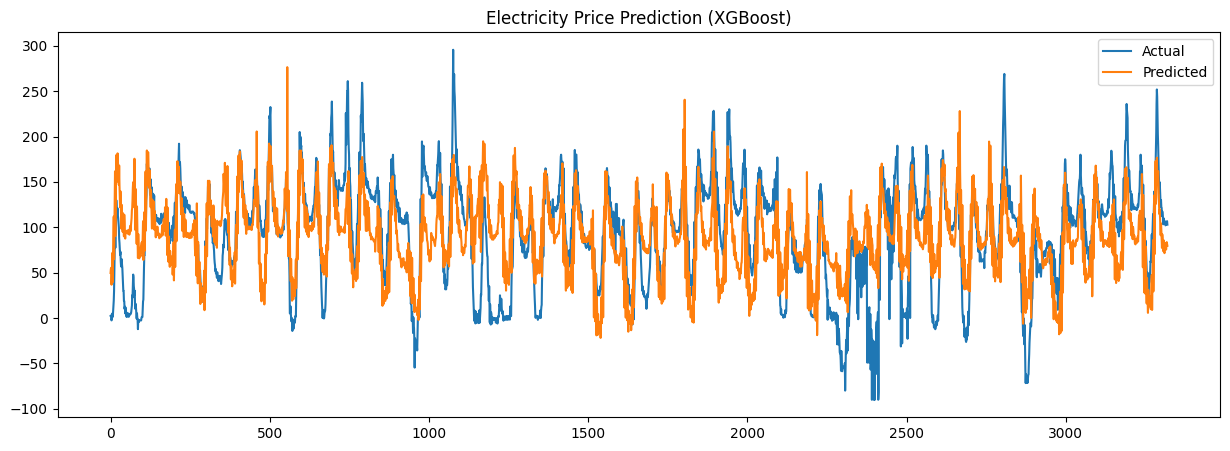

In [173]:
plt.figure(figsize=(15,5))

plt.plot(y_test.values[6000:], label="Actual")
plt.plot(y_pred[6000:], label="Predicted")

plt.legend()
plt.title("Electricity Price Prediction (XGBoost)")
plt.show()

In [194]:
# Walk-forward forecasting (multi-step horizon)
window_size = 30000      # training history size
step_size = 672          # 1 week (retrain frequency)
horizon = 288            # 3-day ahead prediction

preds = []
actuals = []
pred_index = []


columns_to_drop = [
    "DateTime(UTC)",
    "ActualGenerationOutput[MW]",
    "ActualConsumption[MW]",
    "date",
    "Price[Currency/MWh]", 
    "target_288"
]
print(len(df_model) - horizon)
for i in range(window_size, len(df_model) - horizon, step_size):

    # 🔹 training window (rolling)
    train = df_model.iloc[i - window_size:i]
    
    # 🔹 test window (next week chunk)
    test = df_model.iloc[i:i + step_size]

    X_train = train.drop(columns=columns_to_drop)
    y_train = train["target_288"]

    X_test = test.drop(columns=columns_to_drop)

    # 🔹 retrain model weekly
    model = XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)

    # 🔹 predict
    y_pred = model.predict(X_test)
   

    preds.extend(y_pred)
    actuals.extend(df_model.iloc[i + horizon:i + horizon + len(test)]["Price[Currency/MWh]"].values)
    pred_index.extend(df_model.iloc[i + horizon:i + horizon + len(test)]["DateTime(UTC)"].values)
    print(len(preds), len(actuals))


44165
672 672
1344 1344
2016 2016
2688 2688
3360 3360
4032 4032
4704 4704
5376 5376
6048 6048
6720 6720
7392 7392
8064 8064
8736 8736
9408 9408
10080 10080
10752 10752
11424 11424
12096 12096
12768 12768
13440 13440
14112 14112
14453 14165


In [198]:
min_len = min(len(preds), len(actuals), len(pred_index))

preds = preds[:min_len]
actuals = actuals[:min_len]
pred_index = pred_index[:min_len]

results = pd.DataFrame({
    "DateTime": pred_index,
    "Actual": actuals,
    "Predicted": preds
})

results = results.sort_values("DateTime").reset_index(drop=True)

mae = mean_absolute_error(results["Actual"], results["Predicted"])
rmse = np.sqrt(mean_squared_error(results["Actual"], results["Predicted"]))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 29.82276075022003
RMSE: 40.903931572756555


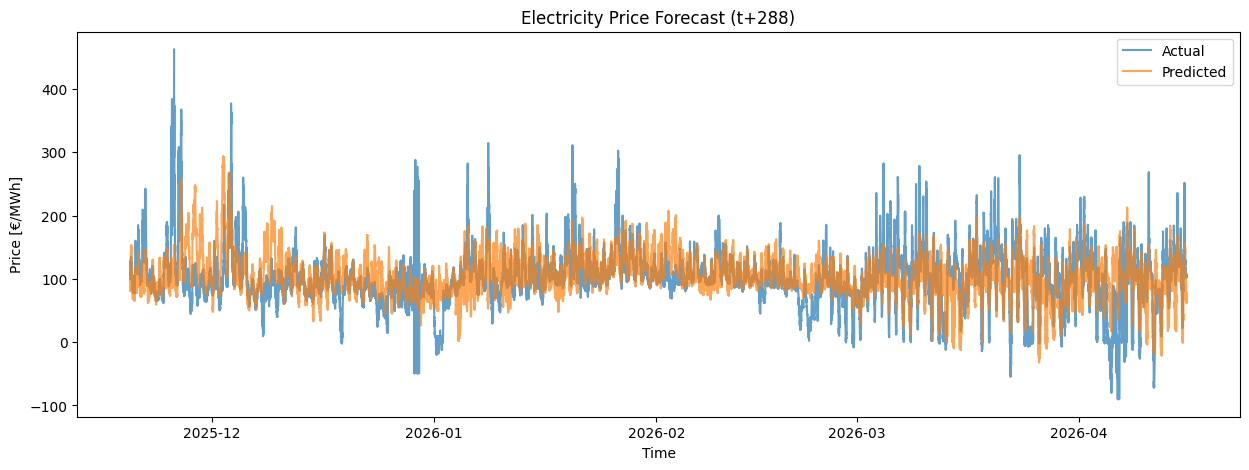

In [199]:

plt.figure(figsize=(15,5))
plt.plot(results["DateTime"], results["Actual"], label="Actual", alpha=0.7)
plt.plot(results["DateTime"], results["Predicted"], label="Predicted", alpha=0.7)

plt.legend()
plt.title("Electricity Price Forecast (t+288)")
plt.xlabel("Time")
plt.ylabel("Price [€/MWh]")
plt.show()

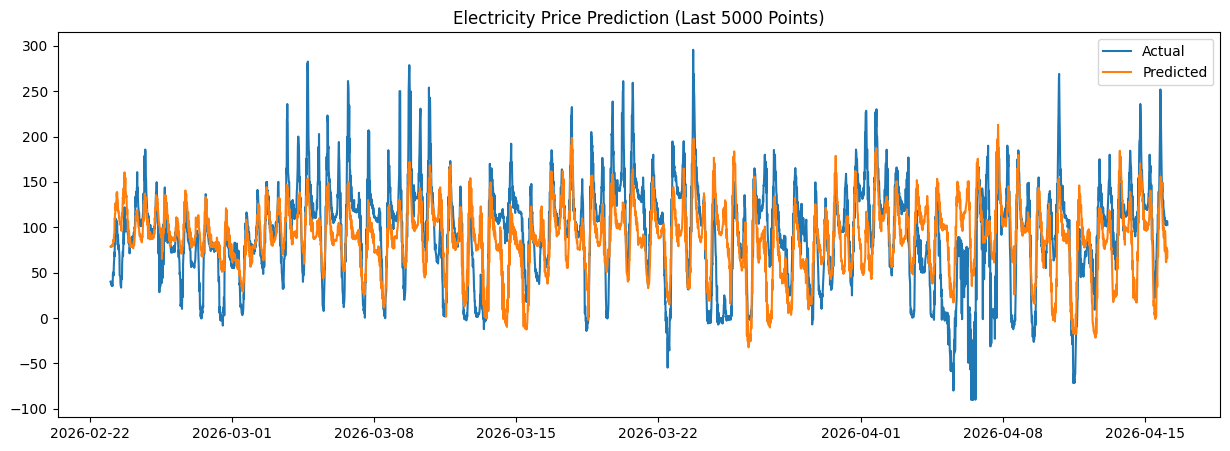

In [200]:

last_n = 5000
zoom = results.iloc[-last_n:]

plt.figure(figsize=(15,5))
plt.plot(zoom["DateTime"], zoom["Actual"], label="Actual")
plt.plot(zoom["DateTime"], zoom["Predicted"], label="Predicted")

plt.legend()
plt.title("Electricity Price Prediction (Last 5000 Points)")
plt.show()